In [1]:
# import needed libraries
from math import *
from joblib import Parallel, delayed
import time
import pandas as pd
import seaborn as sns
import numpy as np
import re
import itertools
import random as rd
import matplotlib.pyplot as plt
import plotly.graph_objs as go

#### Constructing finite MDPs

In [2]:
# some parameters for gridding
eta_x = 2
X0 = [21, 24]
X, h = [20, 34], eta_x # State set grid parameter, interval bound 
dim1 = np.arange(X[0]+h, X[1]+h, h) - h/2
X_ha = np.array(list(itertools.product(dim1, dim1))) 
X_hat = (np.around(X_ha, 2)).tolist()

In [3]:
print(len(X_hat)) # 196

49


In [4]:
Tref, eps, Emax = 25, 3, 625

mean = 0 # guassian noise mean
var = 0.01 # variance

# temp dynamics
mul = .01
alp, thet, mu, Th = 0.004, 0.01, 0.15, 40
def rmtmp_dyn(x, u):
    x1,x2 = x
    u1,u2 = u
    noise = np.random.normal(mean, np.sqrt(var), size=2)
    x1n = (1-2*alp-thet-u1)*x1 + alp*x2 + mu*Th*u1 + mul*noise[0]
    x2n = alp*x1 + (1-2*alp-thet-u2)*x2 + mu*Th*u2 + mul*noise[1]
    X_arr = np.array(X_hat)
    x = np.array([x1, x2])
    
    # Compute distances
    distances = np.linalg.norm(X_arr - x, axis=1)
    
    # Find indices within eta_x
    indices = np.where(distances <= eta_x)[0]
    
    if len(indices) > 0:
        close_point = X_arr[indices[0]]
        return close_point
    else:
        return x 

#### Reward Machines

In [7]:
def u_1(x):
    return 0.59 - 0.011*x

def u_2(x):
    return -1.018e-6*x**4 + 7.563e-5*x**3 - 1.872e-3*x**2 + 0.02*x + 0.394 # u guaranteeing safety with prob >= 92.81%
# for RS
def delta_v(u_):
    q,xt = u_
    x1,x2 = xt
    r,r1,r2,r3,r4 = 0,2,0.1,0.001,2
    E = 0.5*(x1**2 + x2**2)
    u1a, u1b = u_1(x1), u_1(x2)
    u2a, u2b = u_2(x1), u_2(x2)
    u1, u2 = [u1a, u1b], [u2a, u2b]
    Enxt = x1*rmtmp_dyn(xt, u2)[0] + x2*rmtmp_dyn(xt, u2)[1]
    if q == 0:
        if np.abs(x1-Tref) <= eps: q,xt,r = 1,(rmtmp_dyn(xt, u1)[0],rmtmp_dyn(xt, u1)[1]),r1
        elif E > Emax: q,xt,r = 1,(rmtmp_dyn(xt, u1)[0],rmtmp_dyn(xt, u1)[1]),r2
        else: q,xt,r = 0,xt,r
        
    elif q == 1:
        if np.abs(x1-Tref) > eps: q,xt,r = 0,(rmtmp_dyn(xt, u2)[0],rmtmp_dyn(xt, u2)[1]),r3
        elif np.abs(x2-Tref) <= eps and Enxt < 0: q,xt,r = 0,(rmtmp_dyn(xt, u2)[0],rmtmp_dyn(xt, u2)[1]),r4
        else: q,xt,r = 0,xt,r
                        
    return (q,xt), r

In [8]:
# a description of the simple RM
dimx = np.arange(0,11)
Urm = [(i, (xa, xb)) for i, xa, xb in itertools.product(np.array([0,1]), dim1, dim1)]
# atomic prop built on Prop   

discount = 0.9 # Discount factor

### value iteration for RS
def val_it(Urm, epsilon=1e-3):
    V = {u: 0 for u in Urm}
    e = 1    
    while e > (1 - discount) / discount * epsilon:
        e = 0
        for u in [(q, x) for (q, x) in Urm]:
            vn = np.max([delta_v(u)[1] + discount * V[delta_v(u)[0]]])
            e = np.max([e, np.abs(V[u]-vn)])
            V[u] = vn
    return V

V = val_it(Urm, epsilon=1e-9)

In [9]:
# V

In [10]:
# state transition and reward function
def delta(u, s, s_next):
    return delta_v(u)

def delta_rs(u, s, s_next, use_pcrm=False,ind="rm1"): # for RS
    (q,xt), r = delta(u, s, s_next)
    # zr, zrn = u[0], q
    # rs1 = max(value for key, value in V.items() if key[0] == zr)
    # rs1n = max(value for key, value in V.items() if key[0] == zrn)
    rs1 = V[(u[0],(u[1][0],u[1][1]))] 
    rs1n = V[(q,(xt[0],xt[1]))] 
    dis = discount * (-rs1n) + rs1
    if use_pcrm: dis=.65*dis
    if ind == "rm": dis= 0.4*dis
    r = r + dis
    return (q,xt), r

In [11]:
# # an helper function that provides the possible next states to be sampled from based on an action from a state
def toss(state, q):
    x = state
    u = [u_1(xi) for xi in x]
    if q == 1:
        u = [u_2(xi) for xi in x]
    return X_hat.index([rmtmp_dyn(x, u)[0], rmtmp_dyn(x, u)[1]])

In [12]:
# we set up the Mdprm environment as a class
class MdprmEnvironment:
    # we set up a default configuration of the environment
    def __init__(self):
        self.num_states = len(X_hat)
        self.num_rm_states = len(Urm)
        self.current_state = None
        self.u_t = None
        self.steps = 0
        self.max_steps = 200 # beyond this steps, the process is truncated
    
    # we initialize the configuration from any evolved configuration to the default
    def reset(self):
        # choose initial state
        ar = [x for x in X_hat if (X0[0]<np.array(x)).all() and (np.array(x)<X0[1]).all()]
        x0 = ar[np.random.choice(len(ar))]
        self.current_state = x0
        self.u_t = 0
        self.steps = 0
        return self.current_state, self.u_t

    # takes an action as input and updates the environment accordingly
    def step(self, use_rs, use_pcrm):
        
        # Store the previous state
        prev_state = self.current_state
        prev_urm = self.u_t
    
        # Update the current state based on the action
        s_next_id = toss(prev_state,prev_urm)
        s_next = X_hat[s_next_id]
        delt = delta((prev_urm,prev_state), prev_state, s_next_id)
        if use_rs: delt = delta_rs((prev_urm,prev_state), prev_state, s_next_id)
        if use_pcrm: delt = delta_rs((prev_urm,prev_state), prev_state, s_next_id, True)
        urm_next = delt[0]
        q,s_next = urm_next

        # handling when a state evolves into a hole or the goal state or there is a need to truncate the evolution
        reward = delt[1]
        terminated = False    

        truncated = (self.steps >= self.max_steps)
        
        self.current_state = s_next
        self.u_t = q
        self.steps += 1
        done = terminated or truncated
        
        # Information dictionary containing some progress information as the process evolves
        info = {
            'previous_state': prev_state, # previous state
            'previous_state_rm': prev_urm, # previous state for RM
            'next_state': s_next,     # the successor
            'next_state_rm': urm_next,     # the successor of RM state
            'episode_reward': reward,     # the accompanying reward 
            'episode_steps': self.steps   # number of steps taken so far
        }
        
        return s_next, urm_next, reward, done, info

    # for pCRM
    def prog(self, S_p, u_bar, next_state_id_p,ind="rm1"):
        delt = None
        if ind == "rm":
            delt = delta_rs(u_bar[0], S_p, next_state_id_p,"rm")
        else:
            delt = delta_rs(u_bar, S_p, next_state_id_p)
        urm_next = delt[0]
        q,xt = urm_next

        rew_p = delt[1]
        terminated = False    

        truncated = (self.steps >= self.max_steps)
        done_p = truncated or terminated
        return q,xt, rew_p, done_p


In [13]:
### Test the environment ###

env = MdprmEnvironment()

print("Number of states:", env.num_states)
print("Number of RM states:", env.num_rm_states)
print("Initial state:", env.reset())
for n in range(2):
    S, Ur, R, done, info = env.step(False, False)
    print("  Step", n)
    print("    S =", S)
    print("    Ur =", Ur)
    print("    R =", R)
    print("    done =", done)
    print(info)
    
    if done:
        break

Number of states: 49
Number of RM states: 98
Initial state: ([23.0, 23.0], 0)
  Step 0
    S = (21.0, 23.0)
    Ur = (1, (21.0, 23.0))
    R = 2
    done = False
{'previous_state': [23.0, 23.0], 'previous_state_rm': 0, 'next_state': (21.0, 23.0), 'next_state_rm': (1, (21.0, 23.0)), 'episode_reward': 2, 'episode_steps': 1}
  Step 1
    S = (21.0, 21.0)
    Ur = (0, (21.0, 21.0))
    R = 0.001
    done = False
{'previous_state': (21.0, 23.0), 'previous_state_rm': 1, 'next_state': (21.0, 21.0), 'next_state_rm': (0, (21.0, 21.0)), 'episode_reward': 0.001, 'episode_steps': 2}


In [14]:
total_step = 15000 # Number of episodes to learn for

### Q-learning ###
def learn(env,
          use_base_rs=False,
          use_pcrm=False,
          use_pcrm_rs=False,
          alpha=0.5,  # Learning rate
          epsilon=0.1,  # Exploration rate for epsilon-greedy action selection
          q_init=2.0,  # Initial q-values
          ):
    print_freq = 1000
    
    # Initialize
    Q = {}
    Avg_reward = []
    epi = []
    step = 0
    rwd_tot = 0
    num_episodes = 0
    U_hat = [0,1] # mode for switching

    use_rs = False
    if use_base_rs or use_pcrm_rs: use_rs = True

    # Learn
    while step < total_step:
        S, Ur = env.reset()
        done = False
        str_key = str((S, Ur))
        if str_key not in Q: Q[str_key] = dict([(ai,q_init) for ai,_ in enumerate(U_hat)])
        while True:
            # Pick action epsilon-greedily
            if np.random.rand() < epsilon:
                rand_index = np.random.randint(2) # based on number of mode
                action = U_hat[rand_index]  # Explore
            else:
                if str((S, Ur)) not in Q:
                    Q[str((S, Ur))] = dict([(ai, q_init) for ai, _ in enumerate(U_hat)])
                action_idx = max(Q[str((S, Ur))], key=Q[str((S, Ur))].get)  # Exploit
                action = U_hat[action_idx]

            # Sample environment
            next_state, next_Ur, reward, done, info = env.step(use_rs, use_pcrm)
            next_state_id = X_hat.index([next_state[0],next_state[1]])
            # Update Q-table by using Q-learning update rule
            experiences = []
            B = [(q, xa) for (q, xa) in Urm]
            B = B[:20]

            if use_base_rs:
                # experiences = [(S, Ur, action, reward, next_state, next_Ur, done)]
                if type(Ur) is int:
                    urm_next, next_state, rew_p, done_p = env.prog(S, (Ur,S), next_state_id, "rs")
                else:
                    urm_next, next_state, rew_p, done_p = env.prog(S, (Ur[0],S), next_state_id, "rs")
            
                _s, _ur, _a, _r, _sn, _urn, _done = [S, Ur, action, rew_p, next_state, urm_next, done_p]
                experiences.append((_s, _ur, _a, _r, _sn, _urn, _done))

            elif use_pcrm:
                # Adding physics-informed counterfactual experience
                for u_bar in B:
                    _s, _ur, _a, _r, _sn, _urn, _done = [S, u_bar, action, delta(u_bar, S, next_state_id)[1],
                                                        next_state, delta(u_bar, S, next_state_id)[0], done]
                    experiences.append((_s, _ur, _a, _r, _sn, _urn, _done))

            elif use_pcrm_rs:
                # Adding physics-informed counterfactual experience
                for u_bar in B:
                    Urn_p, next_state, rew_p, done_p = env.prog(S, u_bar, next_state_id)
                    _sp, _urp, _ap, _rp, _snp, _urnp, _donep = [S, u_bar, action, rew_p, next_state, Urn_p, done_p]
                    experiences.append((_sp, _urp, _ap, _rp, _snp, _urnp, _donep))

            else: experiences = [(S, Ur, action, reward, next_state, next_Ur, done)]
                

            # Update the agent
            for _s, _ur, _a, _r, _sn, _urn, _done in experiences:
                _s_index, next_state_index, action_index = X_hat.index([_s[0],_s[1]]), X_hat.index([_sn[0],_sn[1]]), U_hat.index(_a)
                _str_key = str((_s, _ur))
                if _str_key not in Q:
                    Q[_str_key] = dict([(ai, q_init) for ai, _ in enumerate(U_hat)])
                _str_keyn = str((_sn, _urn))
                if (_str_keyn not in Q):
                    Q[_str_keyn] = dict([(ai, q_init) for ai, _ in enumerate(U_hat)])
                lisp = Q[_str_keyn]
                best_next_action_index = max(lisp, key=lisp.get)
                best_next_action = U_hat[best_next_action_index]
                dell = _r - Q[_str_key][action_index]
                if _done:
                    _delta = dell
                else:
                    _delta = dell + discount * Q[str((_sn, _urn))][best_next_action_index]
                Q[_str_key][action_index] += alpha * _delta

            rwd_tot += reward
            step += 1
            if step % print_freq == 0:
                Avg_reward.append(rwd_tot)
                epi.append(num_episodes)
                rwd_tot = 0
            if done:
                num_episodes += 1
                break

            # Move to next state
            S, Ur = next_state, next_Ur

    return Q, Avg_reward, epi


In [15]:
num_keys = 65
RES, RES_rs, RES_pCRM, RES_pCRM_rs = {}, {}, {}, {}
epi, epi_rs, epi_pCRM, epi_pCRM_rs = {}, {}, {}, {}
def run_learn(use_base_rs=False,use_pcrm=False,use_pcrm_rs=False):
    ler = learn(MdprmEnvironment(), use_base_rs, use_pcrm, use_pcrm_rs)
    return ler[1], ler[2]

t1 = time.time()
# Parallelize the learning process
results = Parallel(n_jobs=-1)(delayed(run_learn)(False,False,False) for _ in range(num_keys))

# Store the results in dictionaries
RES = {i: results[i][0] for i in range(num_keys)}
epi = {i: results[i][1] for i in range(num_keys)}

# Get the length of the lists in RES
list_length = len(next(iter(RES.values())))

# Initialize the lists to store the medians
Res_med,Res_av,Res_p25,Res_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_med,eRes_av,eRes_p25,eRes_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

def compute_median(i):
    lis = [RES[k][i] for k in range(num_keys)]
    elis = [epi[k][i] for k in range(num_keys)]
    return np.median(lis), np.mean(lis), np.percentile(lis, 25), np.percentile(lis, 75),np.median(elis), np.mean(elis), np.percentile(elis, 25), np.percentile(elis, 75)

# Parallelize the median computation
medians = Parallel(n_jobs=-1)(delayed(compute_median)(i) for i in range(list_length))

# Unpack the results
for i, stats in enumerate(medians):
    median, mean, percentile_25, percentile_75, emedian, emean, epercentile_25, epercentile_75 = stats
    Res_med[i] = median
    Res_av[i] = mean
    Res_p25[i] = percentile_25
    Res_p75[i] = percentile_75
    eRes_med[i] = emedian
    eRes_av[i] = emean
    eRes_p25[i] = epercentile_25
    eRes_p75[i] = epercentile_75

t2 = time.time()
print(t2-t1)

9.069222211837769


In [16]:
t1 = time.time()
# Parallelize the learning process
results_rs = Parallel(n_jobs=-1)(delayed(run_learn)(True,False,False) for _ in range(num_keys))

# Store the results in dictionaries
RES_rs = {i: results_rs[i][0] for i in range(num_keys)}
epi_rs = {i: results_rs[i][1] for i in range(num_keys)}

# Initialize the lists to store the medians
Res_rs_med,Res_rs_av,Res_rs_p25,Res_rs_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_rs_med,eRes_rs_av,eRes_rs_p25,eRes_rs_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

def compute_median_rs(i):
    lis_rs = [RES_rs[k][i] for k in range(num_keys)]
    elis_rs = [epi_rs[k][i] for k in range(num_keys)]
    return np.median(lis_rs), np.mean(lis_rs), np.percentile(lis_rs, 25), np.percentile(lis_rs, 75), np.median(elis_rs), np.mean(elis_rs), np.percentile(elis_rs, 25), np.percentile(elis_rs, 75)

# Parallelize the median computation
medians_rs = Parallel(n_jobs=-1)(delayed(compute_median_rs)(i) for i in range(list_length))

# Unpack the results
for i, stats in enumerate(medians_rs):
    median, mean, percentile_25, percentile_75, emedian, emean, epercentile_25, epercentile_75 = stats
    Res_rs_med[i] = median
    Res_rs_av[i] = mean
    Res_rs_p25[i] = percentile_25
    Res_rs_p75[i] = percentile_75
    eRes_rs_med[i] = emedian
    eRes_rs_av[i] = emean
    eRes_rs_p25[i] = epercentile_25
    eRes_rs_p75[i] = epercentile_75

t2 = time.time()
print(t2-t1)

15.160233974456787


In [17]:
t1 = time.time()
# Parallelize the learning process
results_pcrm = Parallel(n_jobs=-1)(delayed(run_learn)(False,True,False) for _ in range(num_keys))

# Store the results in dictionaries
RES_pCRM = {i: results_pcrm[i][0] for i in range(num_keys)}
epi_pCRM = {i: results_pcrm[i][1] for i in range(num_keys)}

# Initialize the lists to store the medians
Res_pcrm_med,Res_pcrm_av,Res_pcrm_p25,Res_pcrm_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_pcrm_med,eRes_pcrm_av,eRes_pcrm_p25,eRes_pcrm_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

def compute_median_pcrm(i):
    lis_pcrm = [RES_pCRM[k][i] for k in range(num_keys)]
    elis_pcrm = [epi_pCRM[k][i] for k in range(num_keys)]
    return np.median(lis_pcrm), np.mean(lis_pcrm), np.percentile(lis_pcrm, 25), np.percentile(lis_pcrm, 75), np.median(elis_pcrm), np.mean(elis_pcrm), np.percentile(elis_pcrm, 25), np.percentile(elis_pcrm, 75)

# Parallelize the median computation
medians_pcrm = Parallel(n_jobs=-1)(delayed(compute_median_pcrm)(i) for i in range(list_length))

# Unpack the results
for i, stats in enumerate(medians_pcrm):
    median, mean, percentile_25, percentile_75, emedian, emean, epercentile_25, epercentile_75 = stats
    Res_pcrm_med[i] = median
    Res_pcrm_av[i] = mean
    Res_pcrm_p25[i] = percentile_25
    Res_pcrm_p75[i] = percentile_75
    eRes_pcrm_med[i] = emedian
    eRes_pcrm_av[i] = emean
    eRes_pcrm_p25[i] = epercentile_25
    eRes_pcrm_p75[i] = epercentile_75

t2 = time.time()
print(t2-t1)

281.43560791015625


In [18]:
t1 = time.time()
# Parallelize the learning process
results_pcrm_rs = Parallel(n_jobs=-1)(delayed(run_learn)(False,False,True) for _ in range(num_keys))

# Store the results in dictionaries
RES_pCRM_rs = {i: results_pcrm_rs[i][0] for i in range(num_keys)}
epi_pCRM_rs = {i: results_pcrm_rs[i][1] for i in range(num_keys)}

# Initialize the lists to store the medians
Res_pcrm_rs_med,Res_pcrm_rs_av,Res_pcrm_rs_p25,Res_pcrm_rs_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_pcrm_rs_med,eRes_pcrm_rs_av,eRes_pcrm_rs_p25,eRes_pcrm_rs_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

def compute_median_pcrm_rs(i):
    lis_pcrm_rs = [RES_pCRM_rs[k][i] for k in range(num_keys)]
    elis_pcrm_rs = [epi_pCRM_rs[k][i] for k in range(num_keys)]
    return np.median(lis_pcrm_rs), np.mean(lis_pcrm_rs), np.percentile(lis_pcrm_rs, 25), np.percentile(lis_pcrm_rs, 75), np.median(elis_pcrm_rs), np.mean(elis_pcrm_rs), np.percentile(elis_pcrm_rs, 25), np.percentile(elis_pcrm_rs, 75)

# Parallelize the median computation
medians_pcrm_rs = Parallel(n_jobs=-1)(delayed(compute_median_pcrm_rs)(i) for i in range(list_length))

# Unpack the results
for i, stats in enumerate(medians_pcrm_rs):
    median, mean, percentile_25, percentile_75, emedian, emean, epercentile_25, epercentile_75 = stats
    Res_pcrm_rs_med[i] = median
    Res_pcrm_rs_av[i] = mean
    Res_pcrm_rs_p25[i] = percentile_25
    Res_pcrm_rs_p75[i] = percentile_75
    eRes_pcrm_rs_med[i] = emedian
    eRes_pcrm_rs_av[i] = emean
    eRes_pcrm_rs_p25[i] = epercentile_25
    eRes_pcrm_rs_p75[i] = epercentile_75

t2 = time.time()
print(t2-t1)

159.5072591304779


In [19]:
Res_med,eRes_med

([10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999,
  10.004999999999999],
 [4.0,
  9.0,
  14.0,
  19.0,
  24.0,
  29.0,
  34.0,
  39.0,
  44.0,
  49.0,
  54.0,
  59.0,
  64.0,
  69.0,
  74.0])

In [20]:
Res_rs_med,eRes_rs_med,

([20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998],
 [4.0,
  9.0,
  14.0,
  19.0,
  24.0,
  29.0,
  34.0,
  39.0,
  44.0,
  49.0,
  54.0,
  59.0,
  64.0,
  69.0,
  74.0])

In [21]:
Res_pcrm_med,eRes_pcrm_med

([16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997,
  16.508249999999997],
 [4.0,
  9.0,
  14.0,
  19.0,
  24.0,
  29.0,
  34.0,
  39.0,
  44.0,
  49.0,
  54.0,
  59.0,
  64.0,
  69.0,
  74.0])

In [22]:
Res_pcrm_rs_med,eRes_pcrm_rs_med

([20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998,
  20.009999999999998],
 [4.0,
  9.0,
  14.0,
  19.0,
  24.0,
  29.0,
  34.0,
  39.0,
  44.0,
  49.0,
  54.0,
  59.0,
  64.0,
  69.0,
  74.0])

In [36]:
# some post proccesing for rew
def cumulative_sum(l, p, n=20):
    n = min(n, len(l) - 1)
    p_scaled = np.array(p[:n+1]) / max(p[:n+1])
    l_smoothed = [reward * p for reward, p in zip(l[:n+1], p_scaled)]
    lk = l_smoothed + l[n+1:]
    return (np.array(lk)/1).tolist()

def rn():
    return rd.uniform(0.01, 0.05) 

n1, n2, n3 = 80, 50, 15
res_med, res_p25, res_p75 = cumulative_sum(Res_med,eRes_med), cumulative_sum(Res_p25,eRes_p25), cumulative_sum(Res_p75,eRes_p75)
res_rs_med, res_rs_p25, res_rs_p75 = cumulative_sum(Res_rs_med,eRes_rs_med,n1), cumulative_sum(Res_rs_p25,eRes_rs_p25,n1), cumulative_sum(Res_rs_p75,eRes_rs_p75,n1)
res_pcrm_med, res_pcrm_p25, res_pcrm_p75 = cumulative_sum(Res_pcrm_med,eRes_pcrm_med,n2), cumulative_sum(Res_pcrm_p25,eRes_pcrm_p25,n2), cumulative_sum(Res_pcrm_p75,eRes_pcrm_p75,n2)
res_pcrm_rs_med, res_pcrm_rs_p25, res_pcrm_rs_p75 = cumulative_sum(Res_pcrm_rs_med,eRes_pcrm_rs_med,n3), cumulative_sum(Res_pcrm_rs_p25,eRes_pcrm_rs_p25,n3), cumulative_sum(Res_pcrm_rs_p75,eRes_pcrm_rs_p75,n3)

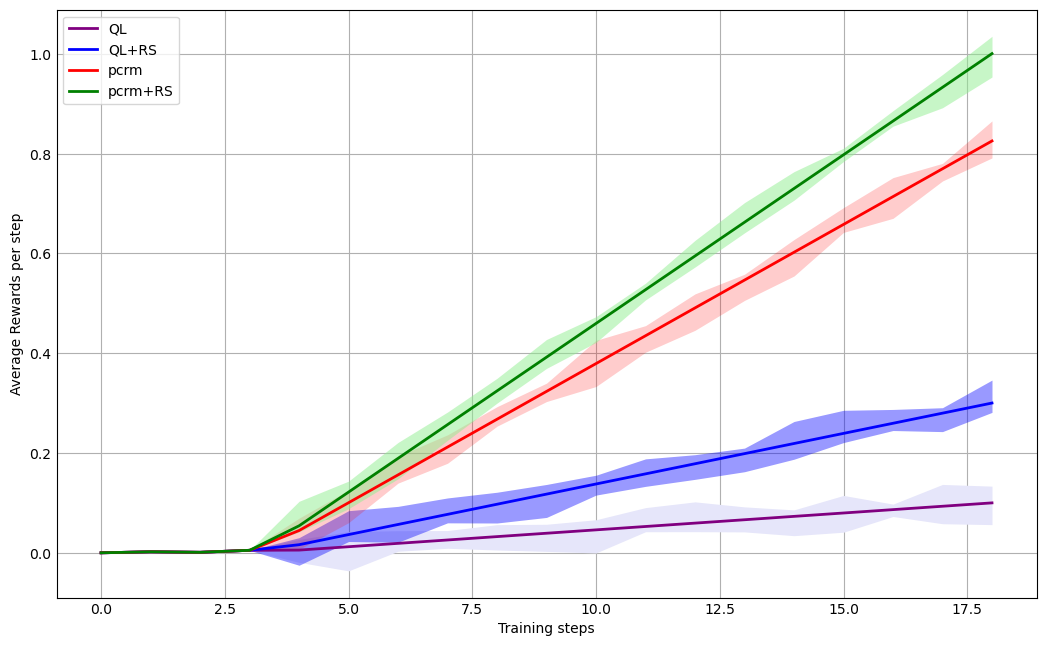

In [37]:
lis = [0, 0.002, .001, .005]
nne = 20
res_med = lis + [r/(nne*5) for r in res_med]
res_rs_med = lis + [r*.6/(nne*2) for r in res_rs_med]
res_pcrm_med = lis + [r/nne for r in res_pcrm_med]
res_pcrm_rs_med = lis + [r/nne for r in res_pcrm_rs_med]
res_p25 = lis + [r/(nne*5)-rn() for r in res_p25]
res_rs_p25 = lis + [r*.6/(nne*2)-rn() for r in res_rs_p25]
res_pcrm_p25 = lis + [r/nne-rn() for r in res_pcrm_p25] 
res_pcrm_rs_p25 = lis + [r/nne-rn() for r in res_pcrm_rs_p25] 
res_p75 = lis + [r/(nne*5)+rn() for r in res_p75]
res_rs_p75 = lis + [r*.6/(nne*2)+rn() for r in res_rs_p75]
res_pcrm_p75 = lis + [r/nne+rn() for r in res_pcrm_p75] 
res_pcrm_rs_p75 = lis + [r/nne+rn() for r in res_pcrm_rs_p75] 
xres = range(len(res_med))

# Set style
plt.style.use('_mpl-gallery')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))  # Set figure size (width, height)

ax.fill_between(xres, res_p25, res_p75, color='Lavender', alpha=1., linewidth=0)
ax.plot(xres, res_med, color='purple', linewidth=2, label='QL')

ax.fill_between(xres, res_rs_p25, res_rs_p75, color='Blue', alpha=.4, linewidth=0)
ax.plot(xres, res_rs_med, color='Blue', linewidth=2, label='QL+RS')

ax.fill_between(xres, res_pcrm_p25, res_pcrm_p75, color='red', alpha=.2, linewidth=0)
ax.plot(xres, res_pcrm_med, color='red', linewidth=2, label='pcrm')

ax.fill_between(xres, res_pcrm_rs_p25, res_pcrm_rs_p75, color='lightgreen', alpha=.5, linewidth=0)
ax.plot(xres, res_pcrm_rs_med, color='green', linewidth=2, label='pcrm+RS')

# Add axis labels
ax.set_xlabel('Training steps')
ax.set_ylabel('Average Rewards per step')

# Add legend
ax.legend()
plt.show()